Long-term impact to biological guilds of PAH toxicity from MPRI2 spill scenarios at Turn Point/Haro Strait

In [1]:
import os
import xarray as xr
import numpy as np
import itertools
import warnings
import pandas as pd
import seaborn as sns
from pathlib import Path
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import ssam_groups as groups
from mpl_toolkits.axes_grid1 import make_axes_locatable

warnings.simplefilter('ignore')

### Define scenario and control files

| Scenarios	|	Description |
|-----------|---------------|
| 0	|	no PAHs, 90d closure |
| 1	|	free PAHs (no management) |
| 2 |   30-day fisheries closures |
| 3	|	90-day fisheries closures |
| 4	|	spill containment within 48hrs |
| 5	|	spill containment within 48hrs + 30-day fisheries closures |
| 6	|	spill containment within 48hrs + 90-day fisheries closures |

8 simulations for each scenario
1. winter S winds
1. winter N winds
1. spring opposing winds & currents
1. spring tandem winds & currents
1. summer Fraser + strong winds
1. summer Fraser + weak winds
1. fall strong N winds
1. fall weak winds

In [2]:
scenario_palette = sns.color_palette([
#'#A17170',
#'#B39595',
'#863092', 
'#A464AD',
'#C297C8', 
#'#DAC0DE' 
'#2F61A4', 
"#6389BB", 
'#97B0D0',
#'#C0CFE5' lightest
])

In [3]:
simulation_palette = sns.color_palette([

'#EE7733','#CC3311', # SUMMER
'#997700', '#666633', #SPRING
'#EE99AA', '#994455', #FALL
'#6699CC', '#004488', #WINTER
])

In [4]:
sim_hue_order = [
    
    'summer_Fraser_strong_winds', 'summer_Fraser_weak_winds',
    'spring_opposing_winds_currents', 'spring_tandem_winds_currents',
    'fall_strong_N_winds', 'fall_weak_winds', 
    'winter_S_winds', 'winter_N_winds',
]

In [13]:
sim_labels = ['2019-01-20','2020-01-24', '2019-04-12','2020-04-11', 
     '2019-07-03','2020-07-05','2019-10-20','2020-10-20',]

In [6]:
custom_order = [
    'small pelagic',  'small demersal', 'small flatfish', 
    'benthopelagic', 'large demersal', 'large flatfish','rockfish',
    'hake','lingcod', 'pollock', 'sandlance','pacific herring', 
    'Chinook', 'Chum', 'Coho','Pink','Sockeye', 'Other salmonids',
    'Hatchery Chinook','Hatchery Coho','Hatchery Sockeye',
    'dogfish','ratfish','sixgill','skates',
    'porpoises', 'seals', 'sealions',
    'resident orcas', 'transient orcas','humpbacks',
    'seagulls','other seabirds',]

## Numbers

In [7]:
dff = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/cohort-numbers.csv")

df_simulations = dff.groupby(['bio_group','sim_description'])['percent_change'].mean()
df_simulations.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI2/data_guilds_simulation_mean_test.csv")

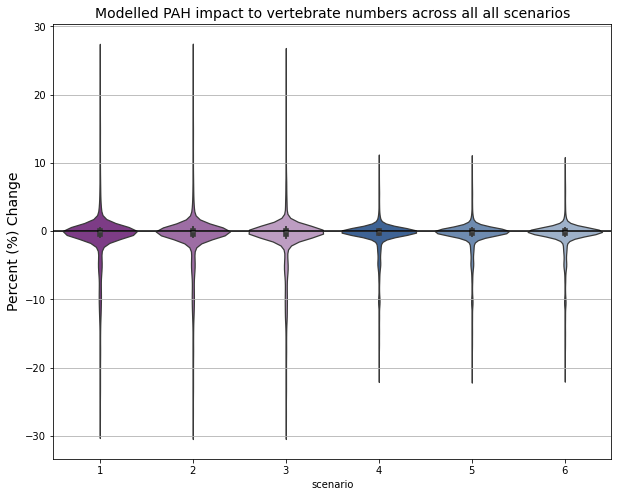

In [35]:
plt.figure(figsize=(10, 8))
plt.grid()
ax = sns.violinplot(dff, x="scenario", y="percent_change", palette=scenario_palette) 
plt.ylabel('Percent (%) Change', fontsize = 14)
plt.title('Modelled PAH impact to vertebrate numbers across all all scenarios', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'

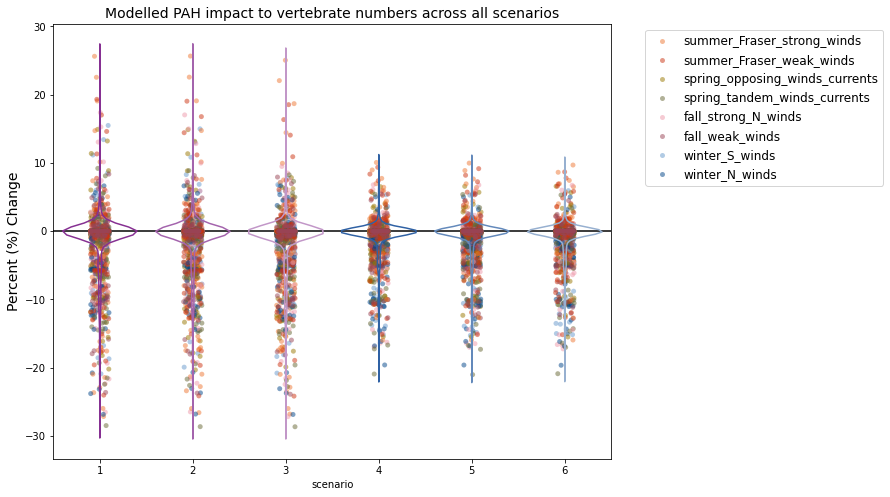

In [37]:
plt.figure(figsize=(10, 8)) 
ax=sns.violinplot(dff, x="scenario", y="percent_change",
    palette=scenario_palette, hue='scenario', fill=False, zorder=10, legend=False) 
sns.stripplot(data=dff, x="scenario",
    y="percent_change", palette=simulation_palette, hue="sim_description", hue_order=sim_hue_order, alpha=0.5, ax=ax)
#plt.ylim(-7.5, 7.5)
plt.ylabel('Percent (%) Change', fontsize = 14)
plt.title('Modelled PAH impact to vertebrate numbers across all scenarios', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.legend(bbox_to_anchor=(1.05, 1), fontsize=12);

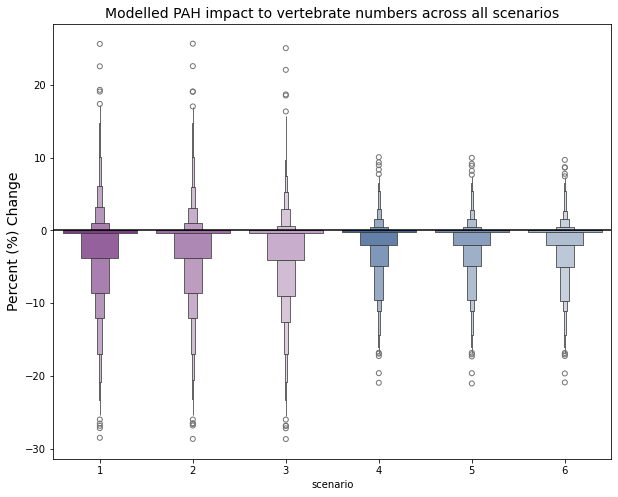

In [39]:
plt.figure(figsize=(10, 8))
ax = sns.boxenplot(dff, x="scenario", y="percent_change", palette=scenario_palette) 
plt.ylabel('Percent (%) Change', fontsize = 14)
plt.title('Modelled PAH impact to vertebrate numbers across all scenarios', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--';

Boxen plots: innermost box is drawn at the lower and upper fourths, incrementally narrower box is drawn between at the lower and upper eighths, and narrower one still at the lower and upper sixteenths (not applicable on this dataset). Tails show the remaining data that exceed the boxes. See the heatmap to know which functional groups correspond to the tails for the scenarios & simulations shown.

compare seasons

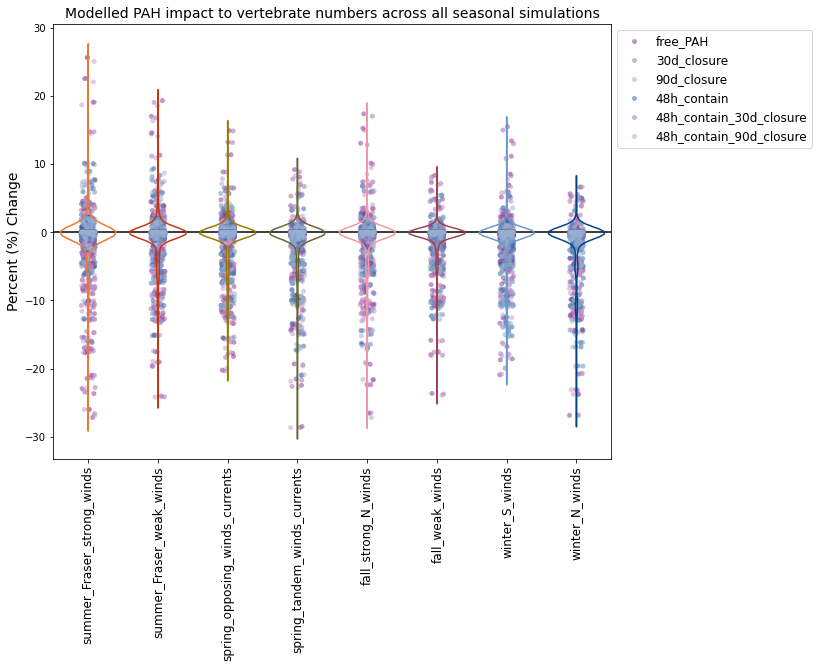

In [41]:
plt.figure(figsize=(10, 8)) 
ax=sns.violinplot(dff, x="sim_description", y="percent_change", order=sim_hue_order,
    palette=simulation_palette, hue='sim_description', hue_order = sim_hue_order, fill=False, zorder=10, legend=False) 
sns.stripplot(data=dff, x="sim_description", 
    y="percent_change", order=sim_hue_order, palette=scenario_palette, hue="description", alpha=0.5, ax=ax)
#plt.ylim(-7.5, 7.5)
plt.ylabel('Percent (%) Change', fontsize = 14)
plt.title('Modelled PAH impact to vertebrate numbers across all seasonal simulations', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.xticks(rotation=90, fontsize=12)
plt.xlabel(None)
plt.legend(bbox_to_anchor=(1, 1), fontsize=12);

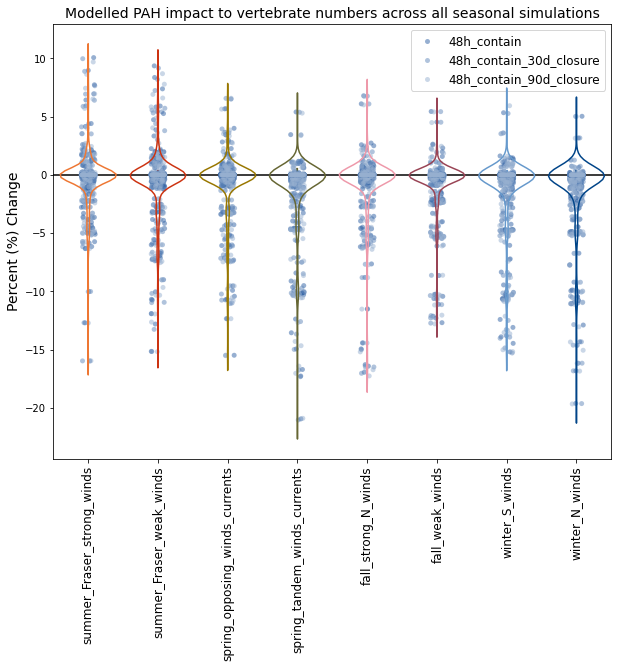

In [42]:
df_plot = dff[(dff['description'].str.contains('48h_contain'))]
plt.figure(figsize=(10, 8)) 
ax=sns.violinplot(df_plot, x="sim_description", y="percent_change", order=sim_hue_order,
    palette=simulation_palette, hue='sim_description', hue_order = sim_hue_order, fill=False, zorder=10, legend=False) 
sns.stripplot(data=df_plot, x="sim_description", 
    y="percent_change", order=sim_hue_order, palette=scenario_palette[3:6], hue="description", alpha=0.5, ax=ax)
#plt.ylim(-7.5, 7.5)
plt.ylabel('Percent (%) Change', fontsize = 14)
plt.title('Modelled PAH impact to vertebrate numbers across all seasonal simulations', fontsize = 14)
plt.axhline(0, color='k'); #linestyle='--'
plt.xticks(rotation=90, fontsize=12)
plt.xlabel(None)
plt.legend(bbox_to_anchor=(1, 1), fontsize=12);

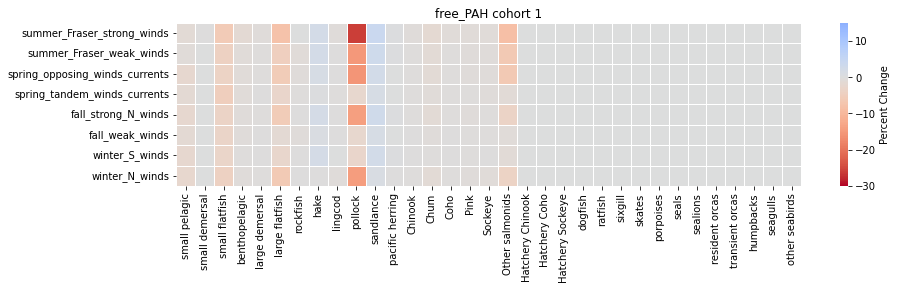

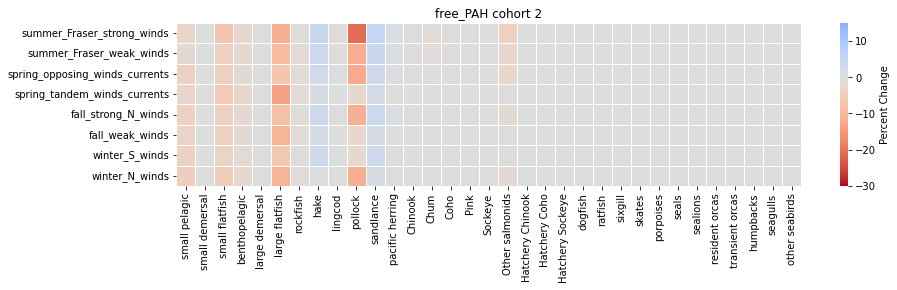

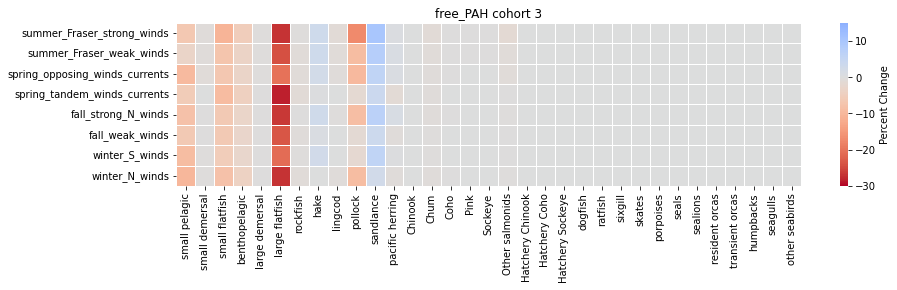

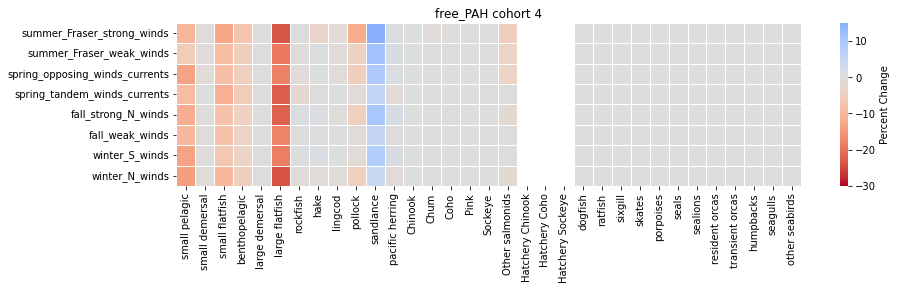

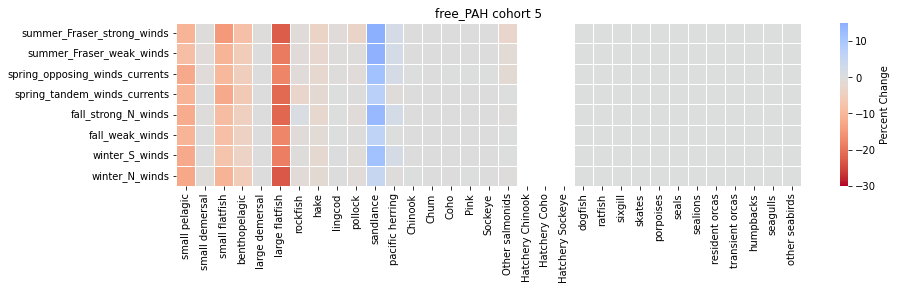

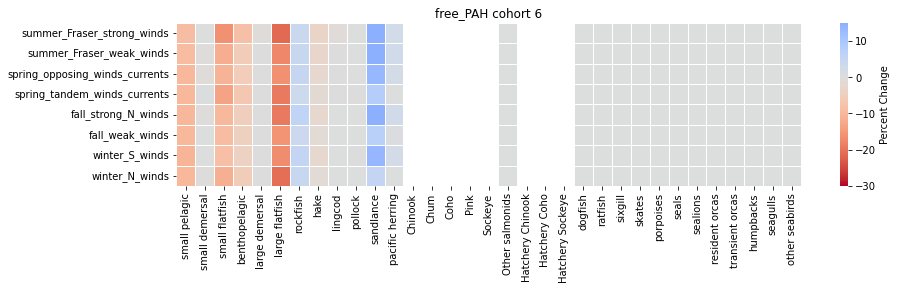

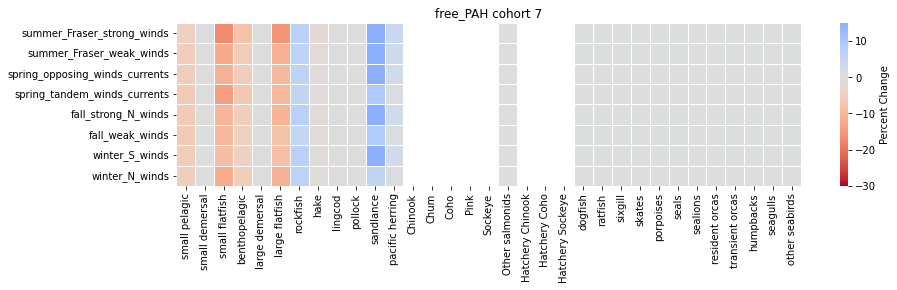

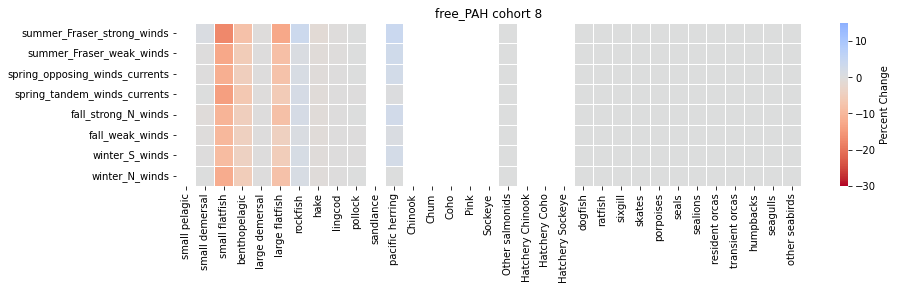

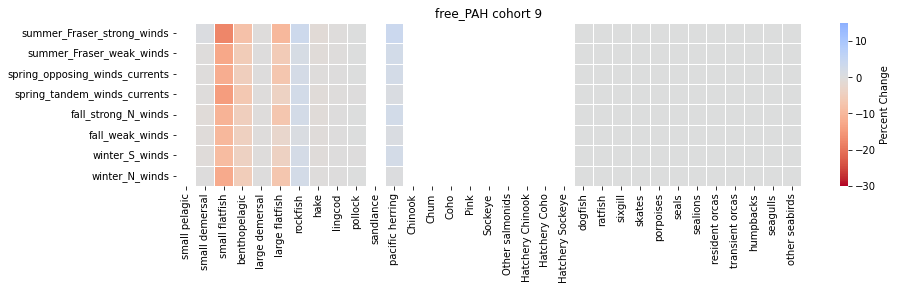

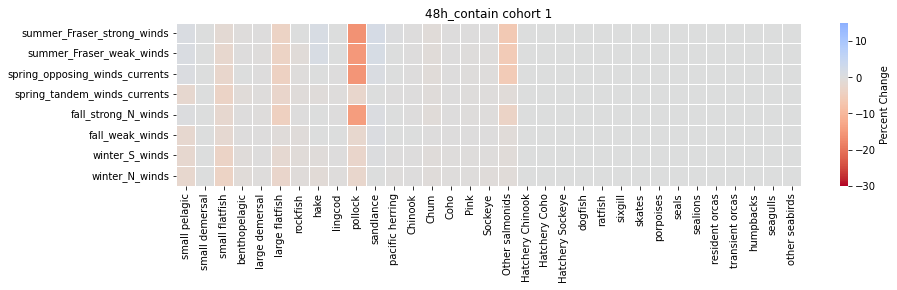

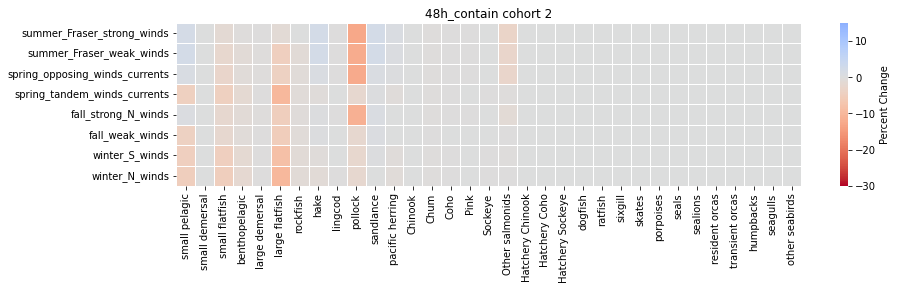

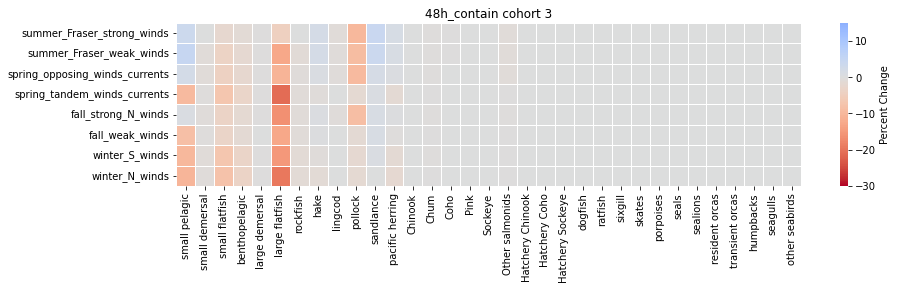

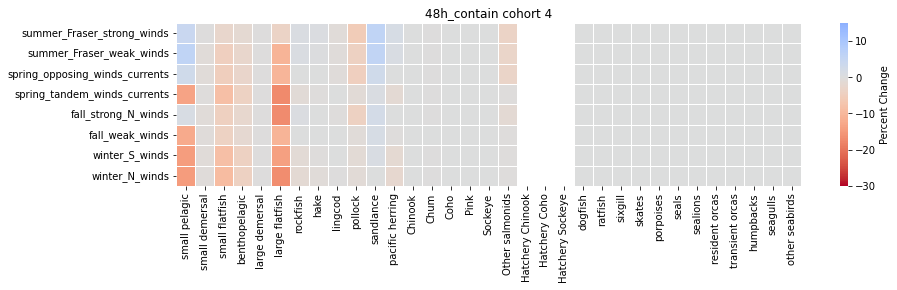

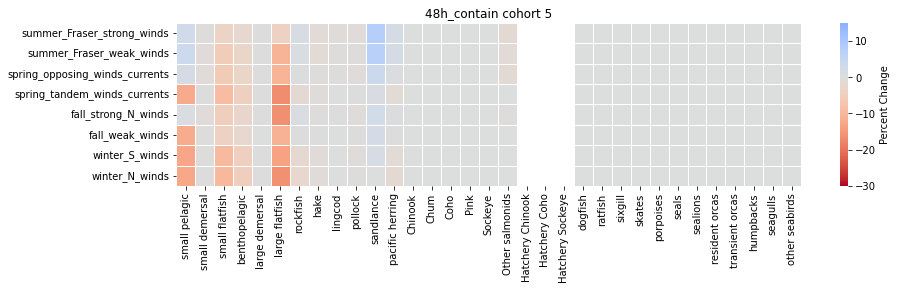

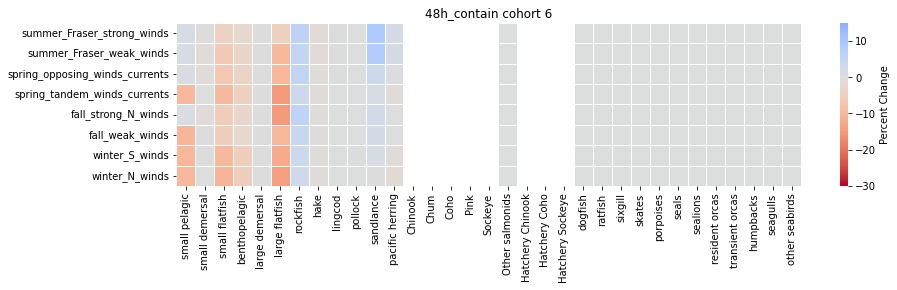

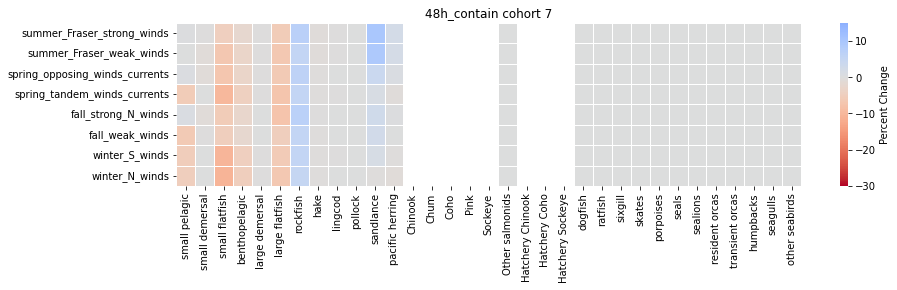

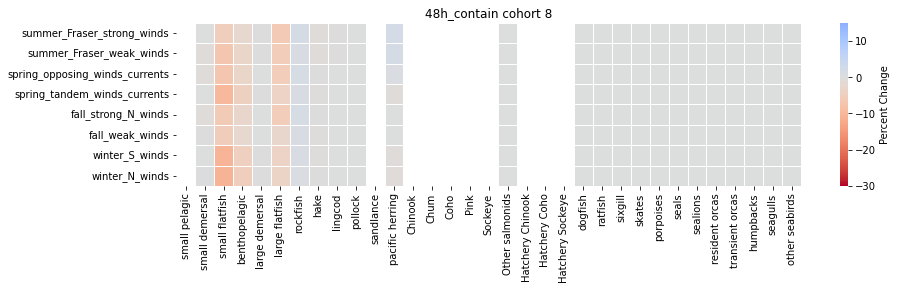

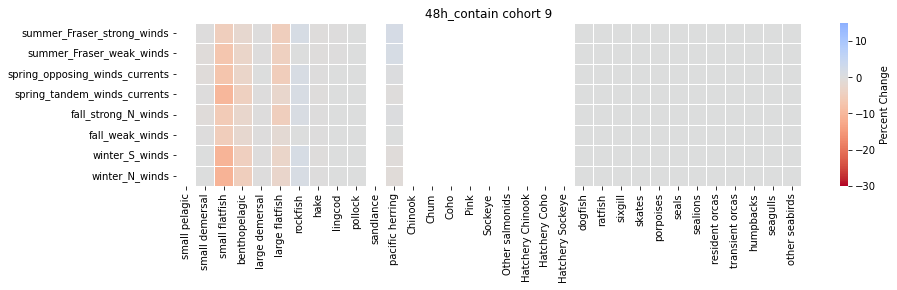

In [32]:
# compared to control
for scenario_label in [1,4]:
    for cohort_count in range(1,10):
        df_plot = dff[(dff['scenario'] == scenario_label) & (dff['cohort'] == cohort_count)]
        heatmap_data = df_plot.pivot(index='sim_description', columns='bio_group', values='percent_change',)
        heatmap_df = heatmap_data.reindex(index=sim_hue_order,columns=custom_order)
        plt.figure(figsize=(14, 3))
        ax = sns.heatmap(
        heatmap_df, 
        annot=False,
        fmt=".1f",
        cmap="coolwarm_r", 
        center=0, vmin=-30, vmax=15,
        linewidths=0.5, 
        #linecolor='gray',
        cbar_kws={'label': 'Percent Change'}
        )
        plt.xlabel(None)
        plt.ylabel(None)
        #for x in bio_boundaries:
        #    ax.vlines(x, *ax.get_ylim(), colors='white', linewidth=6)
        plt.title(groups.scenarios[str(scenario_label)]+' cohort '+str(cohort_count))

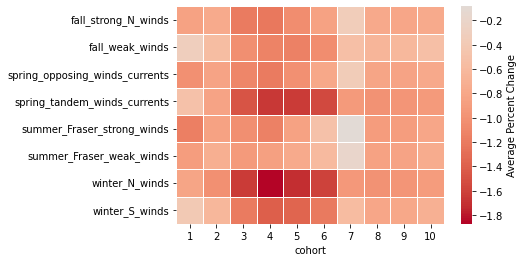

In [50]:
dff.groupby(['cohort','sim_description'])['percent_change'].mean().to_csv('df_cohort_simulations')
df_cohort_sims = pd.read_csv('df_cohort_simulations')
heatmap_df = df_cohort_sims.pivot_table(
    index='sim_description', 
    columns='cohort', 
    values='percent_change',
    )
plt.figure() #figsize=(14, 3)
ax=sns.heatmap(heatmap_df, 
    annot=False, 
    fmt=".1f",
    cmap="coolwarm_r", 
    center=0, 
    linewidths=0.5, 
    #linecolor='gray',
    cbar_kws={'label': 'Average Percent Change'},
)
plt.ylabel(None);
plt.savefig('Fig-hm-average-cohort-vs-simulation-numbers.png',bbox_inches='tight',dpi=300);

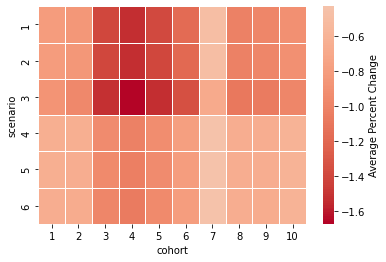

In [51]:
dff.groupby(['cohort','scenario'])['percent_change'].mean().to_csv('df_cohort_scenarios')
sim_plot = pd.read_csv('df_cohort_scenarios')
heatmap_df = sim_plot.pivot_table(
    index='scenario', 
    columns='cohort', 
    values='percent_change',
    )
plt.figure() #figsize=(14, 3)
ax=sns.heatmap(heatmap_df, 
    annot=False, 
    fmt=".1f",
    cmap="coolwarm_r", 
    center=0, 
    linewidths=0.5, 
    #linecolor='gray',
    cbar_kws={'label': 'Average Percent Change'},
    
)
#plt.xticks(ticks=[sim_hue_order], labels=['A','B','C','D','E','F','G','H']) 
plt.savefig('Fig-hm-average-cohort-vs-scenario-numbers.png',bbox_inches='tight',dpi=300);